<a href="https://colab.research.google.com/github/TuanSoCode/Power/blob/main/H%E1%BB%8Dc_Sink.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [244]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vedikagupta0/messy-student-marks-dataset-data-cleaning-practice")

print("Path to dataset files:", path)
import pandas as pd
import numpy as np
!pip install duckdb
import duckdb
import os
print(os.listdir(path))
df=pd.read_csv(path + ("/student_data_part4.csv"))

Using Colab cache for faster access to the 'messy-student-marks-dataset-data-cleaning-practice' dataset.
Path to dataset files: /kaggle/input/messy-student-marks-dataset-data-cleaning-practice
['student_data_part3.csv', 'student_data_part1.csv', 'student_data_part2.csv', 'student_data_part4.csv']


In [245]:
df.head()

,"""Aarav""",male,Grade 12,50.0,23.0,51 marks,124
0,"""Ananya""",m,02,2,26.0,38 marks,66
1,REYANSH,female,04,50.0,83 marks,17,150
2,'Ishaan',female,Grade 7,52,4 marks,20.0,76
3,ADITI,0,012,0.0,50,45,95
4,ARJUN,Male,9,5 marks,40,74.0,119


In [246]:
df.tail()

,"""Aarav""",male,Grade 12,50.0,23.0,51 marks,124
994,AARAV,male,1,14 marks,88,96 marks,198
995,"""Reyansh""",female,3,13,59,47 marks,119
996,'Ishaan',M,Grade 5,37,5,48.0,90
997,ZARA,male,012,64 marks,20.0,7.0,91
998,DIYA,Male,010,65,58 marks,28.0,151


In [247]:
df.duplicated().sum()

np.int64(0)

In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   "Aarav"   999 non-null    object
 1   male      999 non-null    object
 2   Grade 12  999 non-null    object
 3   50.0      999 non-null    object
 4   23.0      999 non-null    object
 5   51 marks  999 non-null    object
 6   124       999 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 54.8+ KB


In [249]:
df.describe()

,124
count,999.000000
mean,147.960961
std,49.036973
min,8.000000
25%,114.000000
50%,149.000000
75%,181.000000
max,300.000000


In [250]:
df.isnull().sum()

,0
"""Aarav""",0
male,0
Grade 12,0
50.0,0
23.0,0
51 marks,0
124,0


In [251]:
df.nunique()

,0
"""Aarav""",80
male,12
Grade 12,36
50.0,291
23.0,296
51 marks,298
124,212


In [252]:
df.rename(columns={'"Aarav"': "Students","male": "Gender","Grade 12":"Grade","50.0":"score_component_1","23.0":"score_component_2","51 marks":"score_component_3","124":"total_score"},inplace=True)

In [253]:
mask=["Students","Gender"]
df[mask]=df[mask].apply(lambda x: x.str.title())
df["Students"]=df["Students"].str.strip('"\'')

In [254]:
df["Grade"]=df["Grade"].str.extract(r'(\d+)').astype(int)

In [255]:
df["Gender"]=df["Gender"].str.strip()
df["Gender"]=df["Gender"].replace({"M":"Male","F":"Female"})
df["Gender"]=df["Gender"].replace(["0","1"],np.nan)

df=df.dropna(subset=["Gender"])
df["score_component_1"]=df["score_component_1"].str.extract(r'(\d+)').astype(int)
df["score_component_2"]=df["score_component_2"].str.extract(r'(\d+)').astype(int)
df["score_component_3"]=df["score_component_3"].str.extract(r'(\d+)').astype(int)

In [256]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [257]:
df.head()

,Students,Gender,Grade,score_component_1,score_component_2,score_component_3,total_score
0,Ananya,Male,2,2,26,38,66
1,Reyansh,Female,4,50,83,17,150
2,Ishaan,Female,7,52,4,20,76
4,Arjun,Male,9,5,40,74,119
6,Isha,Female,12,1,74,36,111


In [258]:
df.nunique()

,0
Students,20
Gender,2
Grade,12
score_component_1,101
score_component_2,101
score_component_3,101
total_score,208


In [259]:
df.groupby("Grade")["total_score"].mean()

,total_score
Grade,
1,144.857143
2,145.178571
3,146.758065
4,149.269231
5,150.278689
6,143.016393
7,150.621622
8,147.073529
9,156.115942


In [260]:
df.tail(50)

,Students,Gender,Grade,score_component_1,score_component_2,score_component_3,total_score
935,Aditi,Male,6,21,35,44,100
937,Shaurya,Female,6,53,63,12,128
938,Diya,Male,9,72,14,51,137
939,Shaurya,Male,9,23,27,92,142
940,Krishna,Female,10,73,84,11,168
942,Vihaan,Male,4,53,44,78,175
943,Kabir,Male,8,94,79,61,234
945,Reyansh,Male,1,47,83,27,157
946,Diya,Male,2,60,48,26,134
947,Aditi,Male,5,74,13,39,126


In [261]:
df.groupby("Grade").size()

,0
Grade,
1,77
2,84
3,62
4,78
5,61
6,61
7,74
8,68
9,69


In [262]:
df.describe()

,Grade,score_component_1,score_component_2,score_component_3,total_score
count,823.000000,823.000000,823.000000,823.000000,823.000000
mean,6.280680,48.512758,48.987849,50.275820,147.776428
std,3.468342,29.289511,28.188276,29.881851,49.273072
min,1.000000,0.000000,0.000000,0.000000,8.000000
25%,3.000000,23.000000,25.000000,22.000000,114.000000
50%,6.000000,48.000000,50.000000,50.000000,148.000000
75%,9.000000,74.500000,72.000000,77.000000,181.000000
max,12.000000,100.000000,100.000000,100.000000,300.000000


In [263]:
duckdb.query(""" SELECT AVG("total_score") as AVG,
MIN("total_score") as Min ,
MAX("total_score") as Max from df """)

┌───────────────────┬───────┬───────┐
│        AVG        │  Min  │  Max  │
│      double       │ int64 │ int64 │
├───────────────────┼───────┼───────┤
│ 147.7764277035237 │     8 │   300 │
└───────────────────┴───────┴───────┘

In [264]:
duckdb.query("""SELECT CASE
WHEN "total_score" < 100 THEN 'Thấp'
WHEN "total_score" < 200
THEN 'TB'
ELSE 'cao'END AS "Nhóm",COUNT(*) AS Students FROM df GROUP BY "Nhóm" """)

┌─────────┬──────────┐
│  Nhóm   │ Students │
│ varchar │  int64   │
├─────────┼──────────┤
│ Thấp    │      139 │
│ TB      │      564 │
│ cao     │      120 │
└─────────┴──────────┘

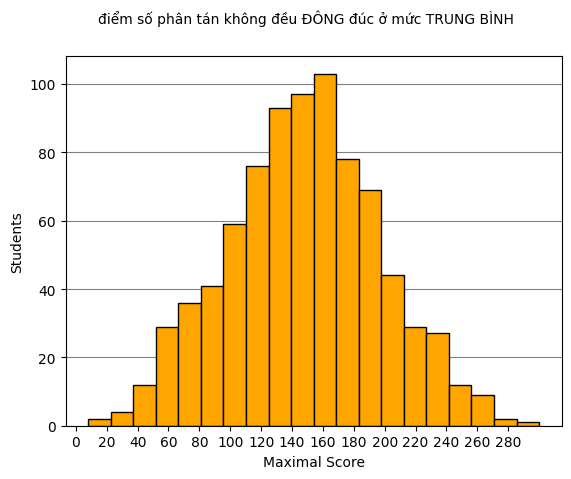

In [265]:
import matplotlib.pyplot as plt
plt.grid(axis="y",zorder= 1,color="gray")
plt.hist(df["total_score"],bins=20, edgecolor="black",color="orange",zorder=2)
plt.ylabel("Students")
plt.xlabel("Maximal Score")
plt.xticks(range(0,300,20))
plt.figtext(0.5,0.95,"điểm số phân tán không đều ĐÔNG đúc ở mức TRUNG BÌNH",ha="center",color="black")
plt.savefig("hoc_sink.png" , dpi=200, bbox_inches="tight")